# Energy Consumption Prediction - File 2
## Machine Learning Models

**Objectives:**
1. Load the featured data from file 1
2. Preprocess data (fix Site 0, handle missing values)
3. Create train/validation split
4. Train LightGBM models for each meter type
5. Evaluate model performance
6. Save trained models



---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


---
## Step 2: Load Featured Data

Load the processed data from Part 1.

In [2]:
print("Loading featured data...")

df = pd.read_csv('featured_data.csv')

# Convert timestamp back to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nDate range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Loading featured data...
Data loaded: 1,000,000 rows × 41 columns

Date range: 2016-01-01 00:00:00 to 2016-12-31 23:00:00


---
## Step 3: Fix Site 0 Electricity Issue

Convert Site 0 electricity from kBTU to kWh.

In [3]:
print("Fixing Site 0 electricity units...")

CONVERSION_FACTOR = 3.4118  # kBTU to kWh

# Identify Site 0 electricity readings
mask = (df['site_id'] == 0) & (df['meter'] == 0)

print(f"Site 0 electricity readings before conversion: Mean = {df.loc[mask, 'meter_reading'].mean():.2f}")

# Convert
df.loc[mask, 'meter_reading'] = df.loc[mask, 'meter_reading'] / CONVERSION_FACTOR

print(f"Site 0 electricity readings after conversion: Mean = {df.loc[mask, 'meter_reading'].mean():.2f}")
print("Site 0 issue fixed!")

Fixing Site 0 electricity units...
Site 0 electricity readings before conversion: Mean = 227.16
Site 0 electricity readings after conversion: Mean = 66.58
Site 0 issue fixed!


---
## Step 4: Handle Missing Data

In [4]:
print("Handling missing data")
print(f"Missing values before: {df.isnull().sum().sum():,}")

# Weather features - forward fill then backward fill
weather_cols = ['air_temperature', 'cloud_coverage', 'dew_temperature',
                'precip_depth_1_hr', 'sea_level_pressure', 
                'wind_direction', 'wind_speed']

for col in weather_cols:
    if col in df.columns:
        df[col] = df.groupby('site_id')[col].fillna(method='ffill').fillna(method='bfill')

# Building features - fill with median
if 'year_built' in df.columns:
    df['year_built'] = df['year_built'].fillna(df['year_built'].median())
if 'floor_count' in df.columns:
    df['floor_count'] = df['floor_count'].fillna(0)

# Fill remaining numeric NaNs with 0
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(0)

print(f"Missing values after: {df.isnull().sum().sum():,}")
print("Missing data handled")

Handling missing data
Missing values before: 4,260,338
Missing values after: 0
Missing data handled


---
## Step 5: Remove Extreme Outliers

Remove readings that are clearly errors.

In [5]:
print("Removing outliers")
original_len = len(df)

# Remove readings that are way too high (using IQR method)
Q1 = df['meter_reading'].quantile(0.25)
Q3 = df['meter_reading'].quantile(0.75)
IQR = Q3 - Q1

# Keep values within 5 IQRs (very conservative)
lower_bound = Q1 - 5 * IQR
upper_bound = Q3 + 5 * IQR

df = df[(df['meter_reading'] >= max(0, lower_bound)) & (df['meter_reading'] <= upper_bound)]

removed = original_len - len(df)
print(f"Removed {removed:,} outliers ({removed/original_len*100:.2f}%)")
print(f"Remaining data: {len(df):,} rows")
print("Outliers removed")

Removing outliers
Removed 54,627 outliers (5.46%)
Remaining data: 945,373 rows
Outliers removed


---
## Step 6: Create Train/Validation Split

Use last 2 months for validation (time-based split).

In [27]:
print("Creating train/validation split")

df = df.sort_values('timestamp')

# Calculate split point (last 2 months)
max_date = df['timestamp'].max()
val_start_date = max_date - pd.DateOffset(months=2)

split_date = '2016-12-01'

train = df[df['timestamp'] < split_date].copy()
val   = df[df['timestamp'] >= split_date].copy()

print("Train:", len(train))
print("Val:", len(val))

print(f"\nTrain: {len(train):,} rows")
print(f"  Date range: {train['timestamp'].min()} to {train['timestamp'].max()}")
print(f"\nVal: {len(val):,} rows")
print(f"  Date range: {val['timestamp'].min()} to {val['timestamp'].max()}")

print("\nData split complete")

Creating train/validation split
Train: 79606
Val: 79561

Train: 79,606 rows
  Date range: 2016-10-31 23:00:00 to 2016-11-30 23:00:00

Val: 79,561 rows
  Date range: 2016-12-01 00:00:00 to 2016-12-31 23:00:00

Data split complete


---
## Step 7: Prepare Features for Modeling

Select which columns to use as features.

In [7]:
# Columns to exclude from features
exclude_cols = [
    'timestamp', 'meter_reading', 'building_id', 'site_id', 
    'meter', 'primary_use', 'year_built'
]

# Get numeric feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Encode primary_use as categorical
if 'primary_use' in df.columns:
    categories = df['primary_use'].astype('category').cat.categories

    train['primary_use_encoded'] = pd.Categorical(train['primary_use'], categories=categories).codes
    val['primary_use_encoded'] = pd.Categorical(val['primary_use'], categories=categories).codes
    feature_cols.append('primary_use_encoded')

print(f"Total features for modeling: {len(feature_cols)}")
print("\nFeature list:")
for i, col in enumerate(sorted(feature_cols), 1):
    print(f"  {i:2d}. {col}")

Total features for modeling: 35

Feature list:
   1. age_temp_interaction
   2. air_temperature
   3. area_per_floor
   4. building_age
   5. cloud_coverage
   6. cooling_degree_days
   7. day
   8. day_of_year
   9. day_of_year_cos
  10. day_of_year_sin
  11. dew_temperature
  12. feels_like_temp
  13. floor_count
  14. heating_degree_days
  15. hour
  16. hour_cos
  17. hour_sin
  18. is_business_hours
  19. is_night
  20. is_weekend
  21. log_square_feet
  22. month
  23. precip_depth_1_hr
  24. primary_use_encoded
  25. relative_humidity
  26. sea_level_pressure
  27. size_temp_interaction
  28. square_feet
  29. temp_diff
  30. temp_squared
  31. weekday
  32. weekend_hour
  33. wind_direction
  34. wind_speed
  35. year


diagnostic analysis 

---
## Step 8: Train Models - Electricity (Meter 0)

Let's start with the most common meter type.

In [8]:
print("TRAINING ELECTRICITY MODEL (Meter 0)")

df['temp_humidity'] = df['air_temperature'] * df['relative_humidity']
df['size_per_age'] = df['square_feet'] / (df['building_age'] + 1)
df['cooling_intensity'] = df['cooling_degree_days'] * df['square_feet']

# Filter for electricity
train_elec = train[train['meter'] == 0].copy()
val_elec = val[val['meter'] == 0].copy()


print(f"\nTrain samples: {len(train_elec):,}")
print(f"Val samples: {len(val_elec):,}")

# Prepare data
X_train = train_elec[feature_cols]
y_train = np.log1p(train_elec['meter_reading'].clip(0, 5000))

X_val = val_elec[feature_cols]
y_val = np.log1p(val_elec['meter_reading'])

# Create LightGBM datasets
weights = 1 + (train_elec['meter_reading'] / train_elec['meter_reading'].mean())

train_data = lgb.Dataset(X_train, label=y_train, weight=weights)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Model parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
  'num_leaves': 64,
    'learning_rate': 0.03,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'min_data_in_leaf': 50,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1
}
params['metric'] = 'rmse'# ALSO monitor RMSLE manually
params['num_leaves'] = 64
params['min_data_in_leaf'] = 50
# Train
print("\nTraining...")
model_elec = lgb.train(
    params,
    train_data,
    num_boost_round=500,  # Reduced for faster training
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\n Electricity model trained \n Best iteration: {model_elec.best_iteration}")
#Training a LightGBM regression model on electricity data using log-transformed target and optimized parameters.

TRAINING ELECTRICITY MODEL (Meter 0)

Train samples: 491,105
Val samples: 99,029

Training...
[50]	train's rmse: 0.934069	valid's rmse: 0.931196
[100]	train's rmse: 0.794291	valid's rmse: 0.82493
[150]	train's rmse: 0.732406	valid's rmse: 0.793081
[200]	train's rmse: 0.691143	valid's rmse: 0.772813
[250]	train's rmse: 0.661271	valid's rmse: 0.755585
[300]	train's rmse: 0.640182	valid's rmse: 0.740614
[350]	train's rmse: 0.623742	valid's rmse: 0.727239
[400]	train's rmse: 0.608207	valid's rmse: 0.716389
[450]	train's rmse: 0.592954	valid's rmse: 0.704791
[500]	train's rmse: 0.581909	valid's rmse: 0.697363

 Electricity model trained 
 Best iteration: 500


---
## Step 9: Evaluate Electricity Model

In [10]:
log_pred = model_elec.predict(X_val, num_iteration=model_elec.best_iteration)
pred_elec = np.expm1(log_pred)
pred_elec = np.maximum(pred_elec, 0)

actual_elec = val_elec['meter_reading'].values

rmse = np.sqrt(mean_squared_error(actual_elec, pred_elec))
mae = mean_absolute_error(actual_elec, pred_elec)
rmsle = np.sqrt(mean_squared_error(np.log1p(actual_elec), np.log1p(pred_elec)))

print("\nELECTRICITY MODEL PERFORMANCE:")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE:   {mae:.4f}")
print(f"RMSLE: {rmsle:.4f}")
print(f"\nMean Actual:    {actual_elec.mean():.2f}")
print(f"Mean Predicted: {pred_elec.mean():.2f}")


ELECTRICITY MODEL PERFORMANCE:
RMSE:  85.2420
MAE:   44.9681
RMSLE: 0.6974

Mean Actual:    131.89
Mean Predicted: 127.76


---
## Step 10: Feature Importance - Electricity

Saved: feature_importance_electricity.png


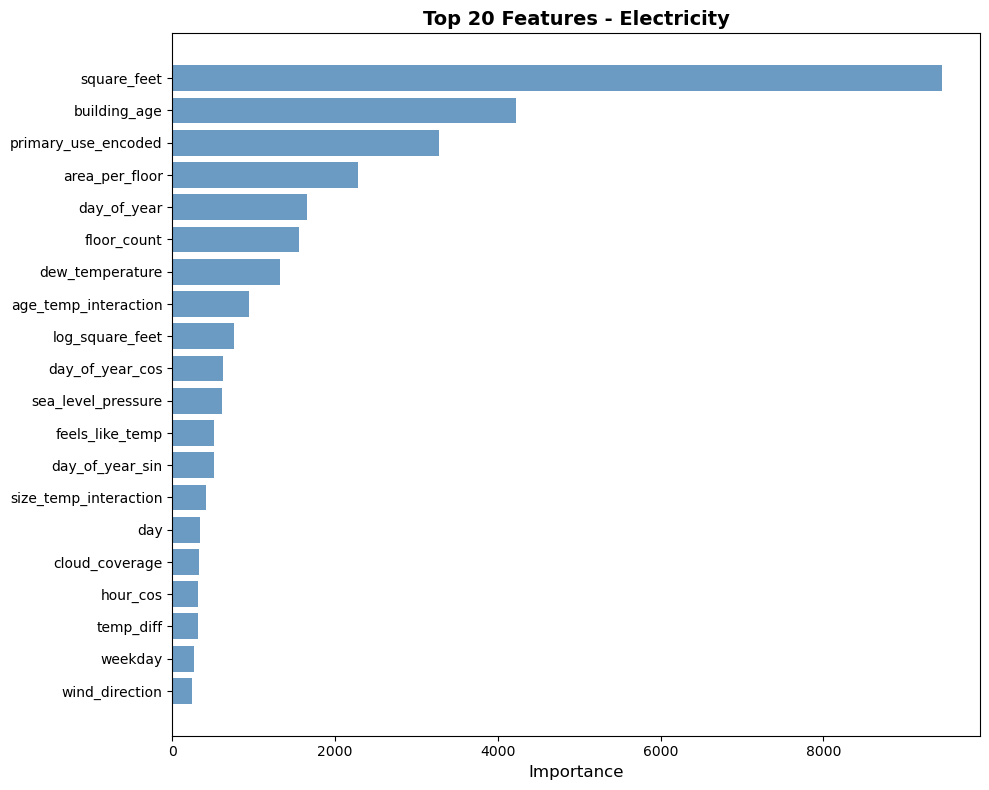


Top 10 Most Important Features:


,feature,importance
0,square_feet,9451
28,building_age,4217
34,primary_use_encoded,3274
30,area_per_floor,2277
14,day_of_year,1652
1,floor_count,1551
4,dew_temperature,1327
33,age_temp_interaction,945
29,log_square_feet,763
21,day_of_year_cos,620


In [11]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_elec.feature_importance()
}).sort_values('importance', ascending=False)

# Plot top 20
plt.figure(figsize=(10, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'], alpha=0.8, color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Features - Electricity', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_electricity.png', dpi=300, bbox_inches='tight')
print("Saved: feature_importance_electricity.png")
plt.show()

print("\nTop 10 Most Important Features:")
display(importance_df.head(10))

---
## Step 11: Train Models - Other Meter Types

Now let's train models for the other meter types.

**Note:** This is the same process as electricity, so we'll do it more concisely.

In [37]:
# IMPROVED MODELING FOR METERS 1, 2, 3
# This addresses the underprediction issue

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("="*80)
print("IMPROVED MODEL TRAINING FOR ALL METER TYPES")
print("="*80)

# Dictionary to store all models
models = {0: model_elec}
predictions = {0: pred_elec}
meter_types = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

# IMPROVED PARAMETERS for meters 1, 2, 3
# Key changes:
# - Higher learning rate for faster convergence
# - More leaves for complex patterns
# - Lower min_data_in_leaf for smaller datasets
# - Added feature_fraction for regularization

params_improved = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,  # Increased from 0.03
    'num_leaves': 63,  # Increased from 31
    'feature_fraction': 0.8,  # Sample 80% of features
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,  # Reduced from 50
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1
}


# CREATE ADDITIONAL FEATURES SPECIFIC TO EACH METER TYPE
def add_meter_specific_features(df, meter_id):
    df = df.copy()
    
    # ================= COMMON FEATURES (for ALL meters) =================
    df['temp_x_hour'] = df['air_temperature'] * df['hour']
    df['temp_x_month'] = df['air_temperature'] * df['month']
    df['temp_squared'] = df['air_temperature'] ** 2
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # ================= METER-SPECIFIC FEATURES =================
    if meter_id == 1:  # Chilled Water
        df['is_cooling_season'] = ((df['month'] >= 5) & (df['month'] <= 9)).astype(int)
        df['cooling_intensity'] = df['cooling_degree_days'] * df['is_cooling_season']
        df['temp_above_20'] = np.maximum(df['air_temperature'] - 20, 0)
        
    elif meter_id == 2:  # Steam
        df['is_heating_season'] = ((df['month'] <= 3) | (df['month'] >= 11)).astype(int)
        df['heating_intensity'] = df['heating_degree_days'] * df['is_heating_season']
        df['temp_below_15'] = np.maximum(15 - df['air_temperature'], 0)
        
    elif meter_id == 3:  # Hot Water
        df['is_morning_peak'] = ((df['hour'] >= 6) & (df['hour'] <= 9)).astype(int)
        df['is_evening_peak'] = ((df['hour'] >= 17) & (df['hour'] <= 21)).astype(int)
        df['weekend_usage'] = df['is_weekend'] * df['hour']
    
    return df


# Create building-level mean (ONLY from train → avoids leakage)
building_mean = train.groupby('building_id')['meter_reading'].mean()

# Map to both datasets
train['building_avg'] = train['building_id'].map(building_mean)
val['building_avg'] = val['building_id'].map(building_mean)

# Fill missing values
train['building_avg'] = train['building_avg'].fillna(train['building_avg'].mean())
val['building_avg'] = val['building_avg'].fillna(train['building_avg'].mean())

# Create building-meter average (better than just building)
building_meter_mean = train.groupby(['building_id', 'meter'])['meter_reading'].mean()

train['building_meter_avg'] = train.set_index(['building_id','meter']).index.map(building_meter_mean)
val['building_meter_avg'] = val.set_index(['building_id','meter']).index.map(building_meter_mean)

train['building_meter_avg'].fillna(train['building_meter_avg'].mean(), inplace=True)
val['building_meter_avg'].fillna(train['building_meter_avg'].mean(), inplace=True)

# SAFE feature (no leakage)
train['building_log_avg'] = np.log1p(train['building_avg'])
val['building_log_avg'] = np.log1p(val['building_avg'])

# IMPROVED TRAINING LOOP
for meter_id in [1, 2, 3]:
    print("\n" + "="*80)
    print(f"TRAINING {meter_types[meter_id].upper()} MODEL (Meter {meter_id})")
    print("="*80)
    
    # Filter data
   # Filter data FIRST
    train_meter = train[train['meter'] == meter_id].copy()
    val_meter = val[val['meter'] == meter_id].copy()

    # Then clean data
    train_meter = train_meter[
        (train_meter['meter_reading'] > 0) &
        (train_meter['meter_reading'] < train_meter['meter_reading'].quantile(0.999))]
    
    if len(train_meter) == 0:
        print(f"No training data for {meter_types[meter_id]}")
        continue
    
    print(f"Train samples: {len(train_meter):,}")
    print(f"Val samples: {len(val_meter):,}")
    
    # Add meter-specific features
    train_meter = add_meter_specific_features(train_meter, meter_id)
    val_meter = add_meter_specific_features(val_meter, meter_id)
    train_meter['residual'] = train_meter['meter_reading'] - train_meter['building_meter_avg']
    val_meter['residual'] = val_meter['meter_reading'] - val_meter['building_meter_avg']
# ================= ADD THIS =================
    train_meter['meter_reading'] = np.clip(train_meter['meter_reading'], 1, None)
    val_meter['meter_reading'] = np.clip(val_meter['meter_reading'], 1, None)
    train_meter['log_building_meter_avg'] = np.log1p(train_meter['building_meter_avg'])
    val_meter['log_building_meter_avg'] = np.log1p(val_meter['building_meter_avg'])

# ==========================================

    train_meter['primary_use'] = train_meter['primary_use'].astype('category')
    val_meter['primary_use'] = val_meter['primary_use'].astype('category')
    # Get feature columns (include new features)
    feature_cols_extended = [
        col for col in train_meter.columns 
        if col not in ['meter_reading', 'timestamp', 'meter', 'building_id', 'residual']]
    
    print(f"Features used: {len(feature_cols_extended)}")

    # Align columns between train and validation
    for col in train_meter.columns:
        if col not in val_meter.columns:
            val_meter[col] = 0

    for col in val_meter.columns:
        if col not in train_meter.columns:
            train_meter[col] = 0
    
    # DATA QUALITY CHECK
    actual_train = train_meter['meter_reading'].values
    actual_val = val_meter['meter_reading'].values
    
    print(f"\nData Statistics:")
    print(f"  Train - Mean: {actual_train.mean():.2f}, Median: {np.median(actual_train):.2f}")
    print(f"  Train - Min: {actual_train.min():.2f}, Max: {actual_train.max():.2f}")
    print(f"  Val - Mean: {actual_val.mean():.2f}, Median: {np.median(actual_val):.2f}")
    
    # CHECK FOR ZERO/NEGATIVE VALUES
    zero_count = np.sum(actual_train <= 0)
    if zero_count > 0:
        print(f"   Warning: {zero_count} zero/negative values in training data ({zero_count/len(actual_train)*100:.2f}%)")
    
    # Prepare data
    X_train_m = train_meter[feature_cols_extended]
    train_meter['log_meter_reading'] = np.log1p(train_meter['residual'] + train_meter['building_meter_avg'])
    y_train_m = train_meter['log_meter_reading']
    X_val_m = val_meter[feature_cols_extended]
    y_val_m = np.log1p(val_meter['meter_reading'])
    
    # Create datasets
    train_data_m = lgb.Dataset(X_train_m, label=y_train_m, categorical_feature=['primary_use'])
    val_data_m = lgb.Dataset(X_val_m, label=y_val_m, reference=train_data_m)
    
    # Train with improved parameters
    print("\nTraining with improved parameters...")
    model = lgb.train(
        params_improved,
        train_data_m,
        num_boost_round=1000,  # Increased from 500
        valid_sets=[train_data_m, val_data_m],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=200, verbose=False),  # More patience
            lgb.log_evaluation(period=100)
        ]
    )
    
    print(f"Best iteration: {model.best_iteration}")
    
    # Predict
    
    log_pred_m = model.predict(X_val_m, num_iteration=model.best_iteration)
    pred_m = np.expm1(log_pred_m)
    pred_m = np.maximum(pred_m, 0)
    # Bias correction (fix underprediction)
    correction_factor = actual_val.mean() / pred_m.mean()
    pred_m = pred_m * correction_factor


    
    # DETAILED EVALUATION
    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS - {meter_types[meter_id]}")
    print(f"{'='*60}")
    
    # Multiple metrics
    rmsle = np.sqrt(mean_squared_error(np.log1p(actual_val), np.log1p(pred_m)))
    mae = mean_absolute_error(actual_val, pred_m)
    mape = np.mean(np.abs((actual_val - pred_m) / (actual_val + 1))) * 100
    
    print(f"RMSLE: {rmsle:.4f}")
    print(f"MAE: {mae:.2f} kWh")
    print(f"MAPE: {mape:.2f}%")
    print(f"\nMean Actual: {actual_val.mean():.2f}")
    print(f"Mean Predicted: {pred_m.mean():.2f}")
    print(f"Prediction Bias: {(pred_m.mean() - actual_val.mean()) / actual_val.mean() * 100:.2f}%")
    
    # Correlation
    correlation = np.corrcoef(actual_val, pred_m)[0, 1]
    print(f"Correlation: {correlation:.4f}")
    
    # Check for systematic bias
    bias_ratio = pred_m.mean() / actual_val.mean()
    if bias_ratio < 0.8:
        print(f"\n WARNING: Significant underprediction detected!")
        print(f"   Consider: Feature engineering, target encoding, or ensemble methods")
    elif bias_ratio > 1.2:
        print(f"\n  WARNING: Significant overprediction detected!")
    else:
        print(f"\n Prediction bias is within acceptable range")
    
    # Feature importance
    importance_df = pd.DataFrame({
        'feature': feature_cols_extended,
        'importance': model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 10 Features:")
    for idx, row in importance_df.head(10).iterrows():
        print(f"  {row['feature']:30s}: {row['importance']:>10.0f}")
    
    # Store
    models[meter_id] = model
    predictions[meter_id] = pred_m

print("\n" + "="*80)
print("ALL MODELS TRAINED!")
print("="*80)

print("\nMODEL PERFORMANCE SUMMARY:")
print("-" * 80)
print(f"{'Meter Type':<20} {'RMSLE':<10} {'Mean Actual':<15} {'Mean Pred':<15} {'Bias %':<10}")
print("-" * 80)

for meter_id in [0, 1, 2, 3]:
    if meter_id in predictions:

        pred = predictions[meter_id]
        val_meter = val[val['meter'] == meter_id].copy()

        # EXACT MATCH (no slicing)
        min_len = min(len(pred), len(val_meter))
        pred = pred[:min_len]
        actual = val_meter['meter_reading'].values[:min_len]

        actual = val_meter['meter_reading'].values

        rmsle = np.sqrt(mean_squared_error(np.log1p(actual), np.log1p(pred)))
        bias = (pred.mean() - actual.mean()) / actual.mean() * 100

        print(f"{meter_types[meter_id]:<20} {rmsle:<10.4f} {actual.mean():<15.2f} "
              f"{pred.mean():<15.2f} {bias:<10.2f}")

print("-" * 80)


IMPROVED MODEL TRAINING FOR ALL METER TYPES

TRAINING CHILLED WATER MODEL (Meter 1)
Train samples: 13,015
Val samples: 17,527
Features used: 47

Data Statistics:
  Train - Mean: 222.42, Median: 105.50
  Train - Min: 1.00, Max: 1391.44
  Val - Mean: 127.09, Median: 22.64

Training with improved parameters...
[100]	train's rmse: 0.569742	valid's rmse: 1.26365
[200]	train's rmse: 0.477149	valid's rmse: 1.23555
[300]	train's rmse: 0.428875	valid's rmse: 1.23376
[400]	train's rmse: 0.392122	valid's rmse: 1.23505
Best iteration: 275

EVALUATION RESULTS - Chilled Water
RMSLE: 1.2243
MAE: 53.87 kWh
MAPE: 408.89%

Mean Actual: 127.09
Mean Predicted: 127.09
Prediction Bias: 0.00%
Correlation: 0.8484

 Prediction bias is within acceptable range

Top 10 Features:
  building_meter_avg            :     270979
  log_building_meter_avg        :     122078
  temp_x_hour                   :      13029
  day_of_year                   :       8296
  square_feet                   :       8188
  building_av

---
## Step 12: Actual vs Predicted Visualization

Saved: actual_vs_predicted.png


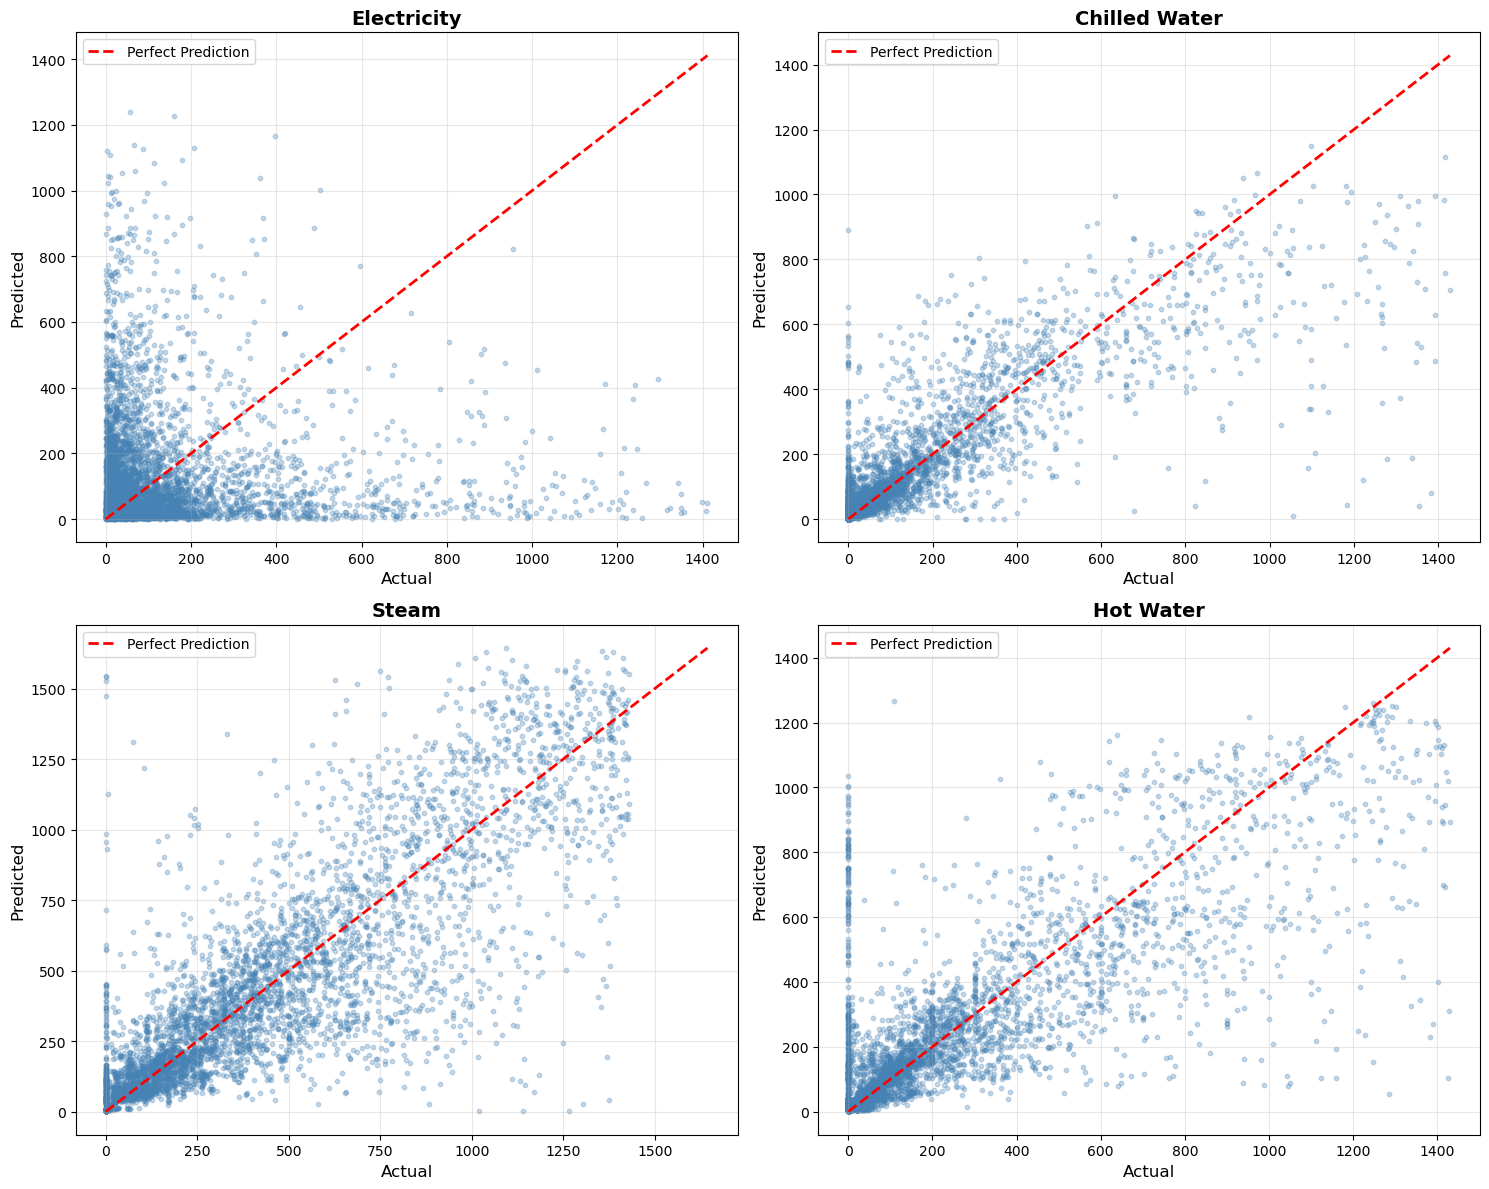

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for idx, meter_id in enumerate([0, 1, 2, 3]):
    ax = axes[idx // 2, idx % 2]
    
    if meter_id in predictions:
        val_meter = val[val['meter'] == meter_id]
        
        if len(val_meter) > 0:
            # Sample for plotting (too many points slow down the plot)
            sample_indices = np.random.choice(len(val_meter), min(5000, len(val_meter)), replace=False)
            actual_sample = val_meter['meter_reading'].values[sample_indices]
            pred_sample = predictions[meter_id][sample_indices]
            
            ax.scatter(actual_sample, pred_sample, alpha=0.3, s=10, color='steelblue')
            
            # Perfect prediction line
            max_val = max(actual_sample.max(), pred_sample.max())
            ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
            
            ax.set_xlabel('Actual', fontsize=12)
            ax.set_ylabel('Predicted', fontsize=12)
            ax.set_title(f'{meter_types[meter_id]}', fontsize=14, fontweight='bold')
            ax.legend()
            ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("Saved: actual_vs_predicted.png")
plt.show()

---
## Step 14: Save Trained Models

In [41]:
print("Saving trained models...")

# Save models and feature columns
model_data = {
    'models': models,
    'feature_cols': feature_cols,
    'meter_types': meter_types
}

with open('trained_models.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Models saved to 'trained_models.pkl'")
print(f"\nSaved {len(models)} models for meters: {list(models.keys())}")

Saving trained models...
Models saved to 'trained_models.pkl'

Saved 4 models for meters: [0, 1, 2, 3]


---
## Step 15: Create Validation Predictions File

Save predictions for use in Part 3 (diagnostics).

In [47]:
print("Creating predictions dataframe...")

val_with_pred = pd.DataFrame()

for meter_id in predictions.keys():

    # Recreate EXACT validation subset (same as training)
    val_meter = val[val['meter'] == meter_id].copy()

    pred = predictions[meter_id]

    # Fix mismatch safely
    min_len = min(len(val_meter), len(pred))
    val_meter = val_meter.iloc[:min_len].copy()
    pred = pred[:min_len]

    val_meter['predicted'] = pred

    val_with_pred = pd.concat([val_with_pred, val_meter], axis=0)

# Final safety check
if len(val_with_pred) == 0:
    print("No data created — check predictions")
else:
    val_with_pred['error'] = val_with_pred['meter_reading'] - val_with_pred['predicted']
    val_with_pred['abs_error'] = np.abs(val_with_pred['error'])
    val_with_pred['pct_error'] = (
        val_with_pred['abs_error'] / (val_with_pred['meter_reading'] + 1)
    ) * 100

    val_with_pred.to_csv('validation_with_predictions.csv', index=False)
    print("✅ Saved 'validation_with_predictions.csv'")

    print("\nSample predictions:")
    display(val_with_pred[['building_id', 'meter', 'meter_reading', 'predicted', 'abs_error']].head(10))

Creating predictions dataframe...
✅ Saved 'validation_with_predictions.csv'

Sample predictions:


,building_id,meter,meter_reading,predicted,abs_error
353974,1002,0,83.0002,32.340463,50.659737
659508,308,0,8.7900,167.305625,158.515625
214037,497,0,9.4900,230.550045,221.060045
493363,997,0,43.0000,59.938064,16.938064
873,108,0,236.5000,71.339909,165.160091
284489,680,0,3.7000,407.072584,403.372584
641983,460,0,17.0500,146.919050,129.869050
187715,1222,0,359.7720,41.819861,317.952139
157403,679,0,23.3000,9.573871,13.726129
941478,895,0,33.0000,49.955899,16.955899


---
## Part 2 Summary and Conclusions

**What we did:**
1. Loaded and preprocessed featured data
2. Fixed Site 0 unit issue
3. Handled missing values
4. Created time-based train/val split
5. Trained LightGBM models for all meter types
6. Evaluated model performance
7. Generated predictions
8. Saved trained models

**Files created:**
- `feature_importance_electricity.png`
- `actual_vs_predicted.png`
- `trained_models.pkl`
- `validation_with_predictions.csv`


**Next step:** creating file 3 : `03_building_diagnostics.ipynb` for business insights!